<a href="https://colab.research.google.com/github/luisleonb/Proyecto_M7_ABP/blob/main/Proyect__M7_ABP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Librerías

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

#Carga y limpieza

In [4]:
df = pd.read_csv('Train.csv')
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [6]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [7]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [ ]:
df.columns

Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='object')

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#columnas
categorical = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1', 'Segmentation']
numerical = ['Age', 'Work_Experience', 'Family_Size']

#pipeline variables categóricas
cat_transform = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop= 'if_binary'))
])

#pipeline variables numéricas
num_transform = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy= 'mean')),
    ('scaler', StandardScaler())
])

#se une todo con el colum transformer
preprocessor = ColumnTransformer(
    transformers=[
      ('num', num_transform, numerical),
      ('cat', cat_transform, categorical)
])

#transformación aplicada al dataframe
X_scaled = preprocessor.fit_transform(df)

In [10]:
X_scaled

array([[-1.28462344, -0.50876333,  0.76700122, ...,  0.        ,
         0.        ,  1.        ],
       [-0.32715082,  0.        ,  0.09997238, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.40826831, -0.50876333, -1.2340853 , ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.62636101, -0.50876333, -1.2340853 , ...,  0.        ,
         0.        ,  1.        ],
       [-0.98541324, -0.50876333,  0.76700122, ...,  1.        ,
         0.        ,  0.        ],
       [-0.38699286, -0.81867058,  0.09997238, ...,  1.        ,
         0.        ,  0.        ]])

##Reducción de dimensionalidad con PCA

In [ ]:
#Eliminar esta celda

from sklearn.decomposition import PCA

pca = PCA(n_components= 0.95)

X_pca = pca.fit_transform(X_scaled)

print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum():.2%}")

Varianza total explicada: 95.46%


In [ ]:
#Si se elimina la celda anterior esta ya no funciona
varianza = pca.explained_variance_ratio_
varianza

array([0.24200407, 0.17103243, 0.12574368, 0.06773239, 0.04857825,
       0.04415675, 0.03880998, 0.03640771, 0.03404097, 0.0262338 ,
       0.02491466, 0.02154103, 0.01771646, 0.01595441, 0.01508178])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

print("Forma de X_scaled:", X_scaled.shape)
print("Varianza total antes de PCA:", np.var(X_scaled, axis=0).sum())

Forma de X_scaled: (8068, 29)
Varianza total antes de PCA: 6.381009098665404


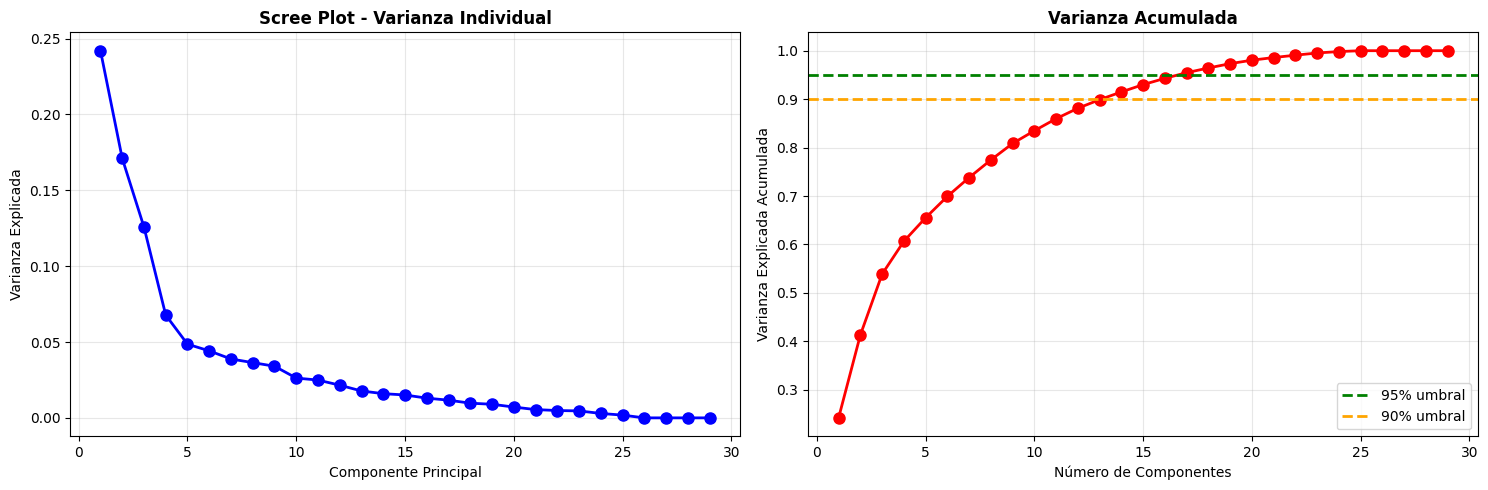

Top 10 componentes - Varianza individual:
   Componente  Varianza  Acumulada
0           1    0.2420     0.2420
1           2    0.1710     0.4130
2           3    0.1257     0.5388
3           4    0.0677     0.6065
4           5    0.0486     0.6551
5           6    0.0442     0.6992
6           7    0.0388     0.7381
7           8    0.0364     0.7745
8           9    0.0340     0.8085
9          10    0.0262     0.8347

Componentes para 90% varianza: 14
Componentes para 95% varianza: 17


In [ ]:
# 1. PCA completo para análisis
pca_full = PCA() #Calcula todos los componentes
pca_full.fit(X_scaled) #Aprendizaje

# Varianzas por componente
varianza_individual = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_individual)

# 2. Gráficos para justificar decisión
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree Plot (varianza individual)
axes[0].plot(range(1, len(varianza_individual)+1), varianza_individual, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada')
axes[0].set_title('Scree Plot - Varianza Individual', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Varianza Acumulada
axes[1].plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, 'ro-', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='green', linestyle='--', linewidth=2, label='95% umbral')
axes[1].axhline(y=0.90, color='orange', linestyle='--', linewidth=2, label='90% umbral')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Explicada Acumulada')
axes[1].set_title('Varianza Acumulada', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen
print("Top 10 componentes - Varianza individual:")
top10 = pd.DataFrame({
    'Componente': range(1,11),
    'Varianza': varianza_individual[:10],
    'Acumulada': varianza_acumulada[:10]
}).round(4)
print(top10)
print(f"\nComponentes para 90% varianza: {np.argmax(varianza_acumulada >= 0.90) + 1}")
print(f"Componentes para 95% varianza: {np.argmax(varianza_acumulada >= 0.95) + 1}")


In [ ]:
# 3. PCA final: 95% varianza explicada
pca_final = PCA(n_components=0.95, random_state=42)
X_pca = pca_final.fit_transform(X_scaled)

print(f"✅ Componentes elegidos automáticamente: {pca_final.n_components_}")
print(f"✅ Varianza total explicada: {pca_final.explained_variance_ratio_.sum():.2%}")
print(f"Forma X_pca: {X_pca.shape}")

# Para visualización 2D (primeras 2 PCs)
X_pca_2d = pca_final.transform(X_scaled)[:, :2]
print(f"Forma X_pca_2d (para gráficos): {X_pca_2d.shape}")


✅ Componentes elegidos automáticamente: 17
✅ Varianza total explicada: 95.46%
Forma X_pca: (8068, 17)
Forma X_pca_2d (para gráficos): (8068, 2)


95% de varianza capturada con 15 componentes

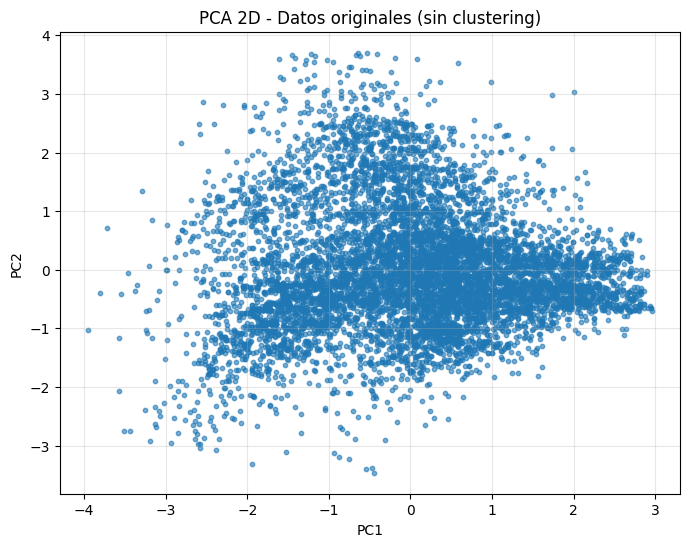

In [ ]:
# PCA 2D para primera visualización (primeras 2 componentes)
X_pca_2d = pca_final.transform(X_scaled)[:, :2]

plt.figure(figsize=(8,6))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], alpha=0.6, s=10)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D - Datos originales (sin clustering)')
plt.grid(True, alpha=0.3)
plt.show()


##K-Means

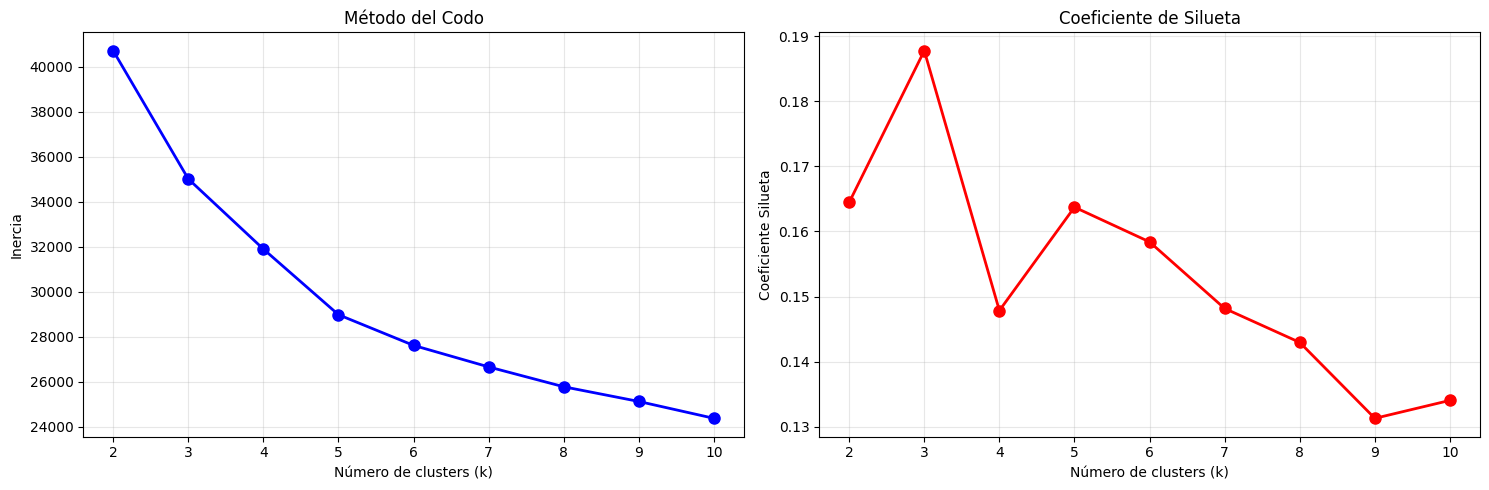

✅ k óptimo por silueta: 3 (silueta=0.188)
Silueta K-Means (3): 0.188


In [ ]:
# K-Means: Método del codo + Silueta
inercia = []
siluetas = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inercia.append(kmeans.inertia_)
    siluetas.append(silhouette_score(X_pca, kmeans.labels_))

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Codo
axes[0].plot(k_range, inercia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')
axes[0].grid(True, alpha=0.3)

# Silueta
axes[1].plot(k_range, siluetas, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Coeficiente Silueta')
axes[1].set_title('Coeficiente de Silueta')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Elegir k óptimo (codo + máxima silueta)
k_optimo = k_range[np.argmax(siluetas)]
print(f"✅ k óptimo por silueta: {k_optimo} (silueta={max(siluetas):.3f})")

# K-Means final
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans_final.fit_predict(X_pca)
print(f"Silueta K-Means ({k_optimo}): {silhouette_score(X_pca, df['cluster_kmeans']):.3f}")


##DBScan

In [ ]:
# DBSCAN (automático, sensible a densidad)
dbscan = DBSCAN(eps=0.5, min_samples=10)  # Ajusta eps si necesitas
df['cluster_dbscan'] = dbscan.fit_predict(X_pca)
n_clusters_dbscan = len(set(df['cluster_dbscan'])) - (1 if -1 in df['cluster_dbscan'] else 0)
n_noise = list(df['cluster_dbscan']).count(-1)

print(f"DBSCAN: {n_clusters_dbscan} clusters, {n_noise} puntos ruido")
if n_clusters_dbscan > 1:
    print(f"Silueta DBSCAN: {silhouette_score(X_pca, df['cluster_dbscan']):.3f}")
else:
    print("DBSCAN: Demasiado ruido para silueta")


DBSCAN: 59 clusters, 6754 puntos ruido
Silueta DBSCAN: -0.310


#Clustering Jerárquico

In [ ]:
# Jerárquico (mismo k que K-Means)
hierarchical = AgglomerativeClustering(n_clusters=k_optimo, linkage='ward')
df['cluster_hier'] = hierarchical.fit_predict(X_pca)
print(f"Silueta Jerárquico ({k_optimo}): {silhouette_score(X_pca, df['cluster_hier']):.3f}")


Silueta Jerárquico (3): 0.163


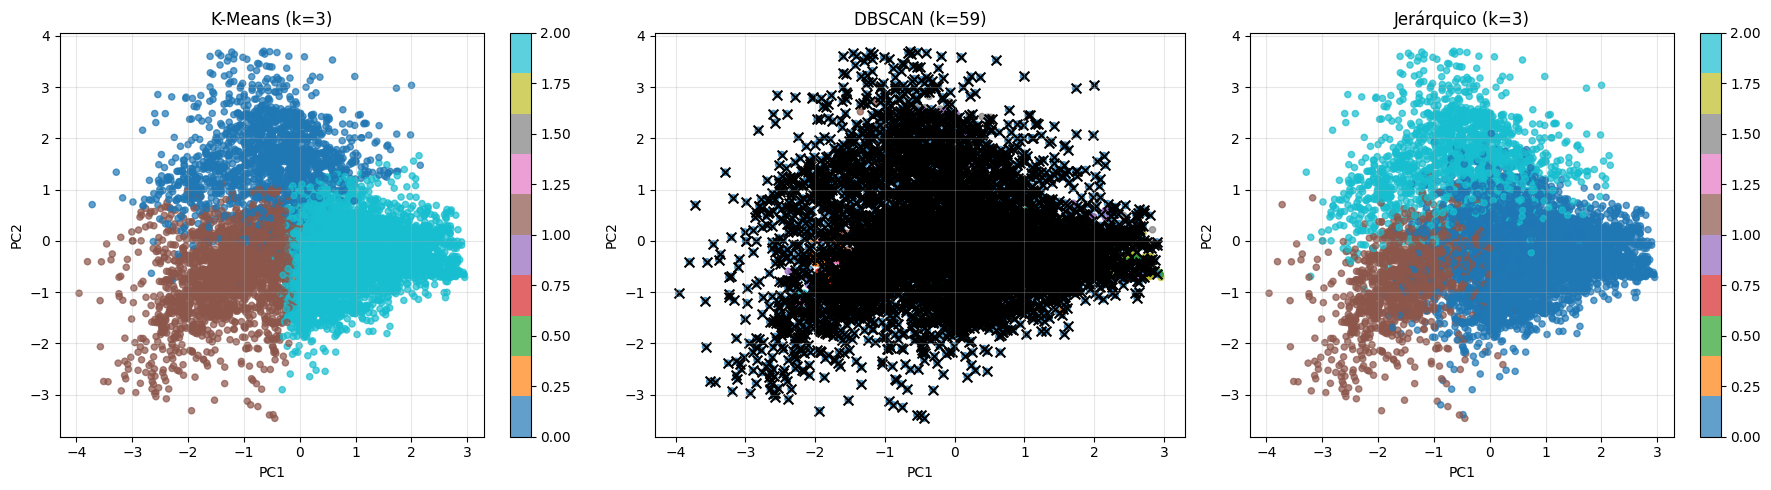

In [ ]:
# Visualización comparativa PCA 2D
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

clusters = ['cluster_kmeans', 'cluster_dbscan', 'cluster_hier']
titulos = ['K-Means', 'DBSCAN', 'Jerárquico']

for i, (col, titulo) in enumerate(zip(clusters, titulos)):
    if col == 'cluster_dbscan':
        scatter = axes[i].scatter(X_pca_2d[:,0], X_pca_2d[:,1],
                                c=df[col], cmap='tab10', alpha=0.7, s=20)
        axes[i].scatter(X_pca_2d[df[col]==-1, 0], X_pca_2d[df[col]==-1, 1],
                       c='black', marker='x', s=50, label='Ruido')
    else:
        scatter = axes[i].scatter(X_pca_2d[:,0], X_pca_2d[:,1],
                                c=df[col], cmap='tab10', alpha=0.7, s=20)

    axes[i].set_xlabel('PC1')
    axes[i].set_ylabel('PC2')
    axes[i].set_title(f'{titulo} (k={len(df[col].unique())})')
    axes[i].grid(True, alpha=0.3)
    if col != 'cluster_dbscan':
        plt.colorbar(scatter, ax=axes[i])

plt.tight_layout()
plt.show()


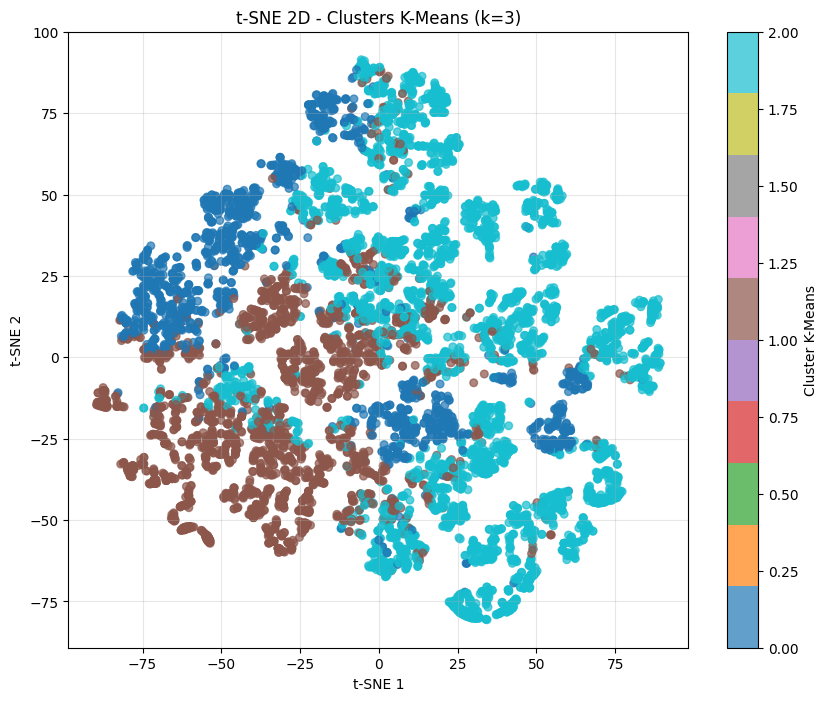

In [ ]:
# t-SNE 2D usando PCA reducido como entrada (más estable)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, learning_rate='auto')
X_tsne = tsne.fit_transform(X_pca)  # <- PCA como entrada!

plt.figure(figsize=(10,8))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df['cluster_kmeans'],
                     cmap='tab10', alpha=0.7, s=30)
plt.colorbar(scatter, label='Cluster K-Means')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title(f't-SNE 2D - Clusters K-Means (k={k_optimo})')
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# Perfiles de cada cluster K-Means (para informe final)
perfil_clusters = df.groupby('cluster_kmeans').agg({
    'Age': ['mean', 'std'],
    'Work_Experience': ['mean'],
    'Family_Size': ['mean'],
    'Spending_Score': lambda x: x.value_counts().index[0],  # Moda
    'Profession': lambda x: x.value_counts().index[0]       # Moda
}).round(2)

print("🔥 PERFIL DE CLUSTERS K-Means (k óptimo):")
print(perfil_clusters)


🔥 PERFIL DE CLUSTERS K-Means (k óptimo):
                  Age        Work_Experience Family_Size Spending_Score  \
                 mean    std            mean        mean       <lambda>   
cluster_kmeans                                                            
0               37.90  10.92            8.30        2.45            Low   
1               28.58   7.54            1.19        3.95            Low   
2               54.31  14.60            0.93        2.38            Low   

                Profession  
                  <lambda>  
cluster_kmeans              
0                   Artist  
1               Healthcare  
2                   Artist  


##Aplicacion de t-SNE

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components= 2)

X_tsne = tsne.fit_transform(X)
